# Feature Engineering

**Feature Engineering** is the process of transforming raw data into features that better represent the underlying problem to predictive models, leading to improved model performance. It is a key step in the machine learning pipeline and often has a greater impact on model accuracy than the choice of model itself.


### 🔧 Key Steps in Feature Engineering

1. **Understanding the Data**

   * Explore and visualize data to identify patterns, trends, outliers.
   * Understand the domain and the meaning of each feature.

2. **Handling Missing Values**

   * Techniques: Imputation (mean/median/mode, KNN), deletion, or special category ("Unknown").

3. **Encoding Categorical Variables**

   * Label Encoding
   * One-Hot Encoding
   * Target Encoding / Mean Encoding
   * Frequency Encoding

4. **Creating New Features**

   * Date & time features: Extract day, month, year, weekday, hour.
   * Text features: Word counts, sentiment scores, TF-IDF, embeddings.
   * Interaction features: Combine two or more features.
   * Aggregations: Mean, sum, count by group.

5. **Scaling/Normalization**

   * StandardScaler (Z-score normalization)
   * MinMaxScaler
   * RobustScaler (for outliers)

6. **Feature Selection**

   * Filter Methods: Correlation, Chi-square.
   * Wrapper Methods: Recursive Feature Elimination (RFE).
   * Embedded Methods: Lasso, decision trees, feature importances.

7. **Dimensionality Reduction**

   * PCA (Principal Component Analysis)
   * t-SNE, UMAP (for visualization)
   * Autoencoders

8. **Dealing with Imbalanced Data**

   * SMOTE (Synthetic Minority Over-sampling Technique)
   * Undersampling
   * Creating ratio-based features


```bash
Original Data: [col1, col2, col3, col4, col5]
              ↓
     ColumnTransformer
       /      |      \
      /       |       \
  PipelineA  PipelineB  remainder
  [col1,2]   [col3,4]   ['drop'/passthrough]
      ↓         ↓           ↓
   outputA   outputB     (nothing)
      \         |         /
       \        |        /
        [combined output]
              ↓
         Next Step in Pipeline
```

**See Run Results :** [https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow](https://dagshub.com/Rahul-404/heart-stroke-prediction.mlflow/#/)

In [ ]:
# TRIGGER_FLAG: run
# KAGGLE_CONFIG: enable_gpu = false
# KAGGLE_CONFIG: enable_tpu = false
# KAGGLE_CONFIG: keywords = ["healthcare", "classification", "data-cleaning"]
# KAGGLE_CONFIG: dataset_sources = ["rahulshelke98/healthcare-dataset-stroke-data-csv"]
# KAGGLE_CONFIG: kernel_sources = ["rahulshelke98/01-02-data-quality-correction", "rahulshelke98/02-03-handling-missing-values", "rahulshelke98/02-04-handling-outliers"]

## Required Installtion

In [ ]:
import os
import sys

# Check if running in Kaggle Cloud Environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    print("--- Kaggle Environment Detected: Installing Cloud Dependencies ---")
    # 1. Install general cloud dependencies
    os.system(f"{sys.executable} -m pip install -q mlflow dagshub")
    
    # 2. Clone the specific branch of the repository
    print("Install custome package...")
    # os.system("git clone -b feat/notebooks https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git")
    os.system(f"{sys.executable} -m pip install -q git+https://github.com/Rahul-Shelke-1/heart-stroke-risk-stratification.git@feat/notebooks")
    
else:
    print("--- Local/Non-Kaggle Environment Detected: Skipping Installation ---")
    # Local packages should ideally be pre-managed via your local uv environment

--- Local/Non-Kaggle Environment Detected: Skipping Installation ---


## Smart Environment Detection & Secrets Setup

In [ ]:
# PRODUCTION MLOPS NOTEBOOK
# Note: This notebook runs automatically in an headless CI/CD pipeline.
# If you fork this notebook to run it yourself, make sure to set up your 
# own DagsHub repository variables or track experiments locally.

import os
import mlflow
from dotenv import load_dotenv

# 1. Safely retrieve credentials from Kaggle's internal secure vault
try:
    # 1. Detect if running inside Kaggle's container
    IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

    if IS_KAGGLE:
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    else:
        load_dotenv()
        DAGSHUB_USERNAME = os.environ.get("DAGSHUB_USERNAME", "Rahul-404")
        DAGSHUB_TOKEN = os.environ.get("DAGSHUB_TOKEN")
    
    # Replace this with your actual DagsHub repo name
    REPO_NAME = "heart-stroke-prediction"
    
    # 2. Inject environment variables that the MLflow client natively looks for
    os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
    os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
    
    # 3. Set the remote tracking URI to point to DagsHub
    tracking_uri = f"https://dagshub.com/{DAGSHUB_USERNAME}/{REPO_NAME}.mlflow"
    mlflow.set_tracking_uri(tracking_uri)
    
    print("Successfully connected to DagsHub MLflow tracking server!")
except Exception as e:
    # print(f"Local or non-Kaggle execution environment detected: {e}")
    print(f"Error establishing MLflow/DagsHub context: {e}")

## Unified Path Setup Strategy

In [ ]:
import os
from pathlib import Path

# 1. Reuse your environment checker flag
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # --- KAGGLE CLOUD PATH CONTEXT ---
    # Fetch environment variables injected by your Kaggle configuration
    KAGGLE_USER = os.environ.get("KAGGLE_USER")
    DATASET_SLUG = os.environ.get("KAGGLE_DATASET_NAME")
    NOTEBOOK_1 = "01-02-data-quality-correction"
    NOTEBOOK_2 = "02-03-handling-missing-values"
    NOTEBOOK_3 = "02-04-handling-outliers"

    # Kaggle mounts datasets directly under /kaggle/input/dataset-slug
    INPUT_DATA_DIR = Path(f"/kaggle/input/datasets/{KAGGLE_USER}/{DATASET_SLUG}")
    INPUT_ARTIFACT_1_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_1}")
    INPUT_ARTIFACT_2_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_2}")
    INPUT_ARTIFACT_3_DIR = Path(f"/kaggle/input/notebooks/{KAGGLE_USER}/{NOTEBOOK_3}")

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Kaggle Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_1_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_1_DIR}")
    
    if not INPUT_ARTIFACT_2_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_2_DIR}")
    
    if not INPUT_ARTIFACT_3_DIR.exists():
        raise FileNotFoundError(f"Kaggle Artifact Directory does not exist: {INPUT_ARTIFACT_3_DIR}")
    
    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_1_DIR,
        'handle_missing': INPUT_ARTIFACT_2_DIR,
        'handle_missing_val': INPUT_ARTIFACT_2_DIR,
        'handle_outlier': INPUT_ARTIFACT_3_DIR
    }
    
    # Kaggle strictly allows file writing ONLY inside /kaggle/working
    OUTPUT_DIR = Path("/kaggle/working")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

else:
    # --- LOCAL ENVIRONMENT PATH CONTEXT ---
    current_directory = Path.cwd()

    # Keeps your local repo clean by saving local run artifacts into an artifacts folder
    OUTPUT_DIR = current_directory / "notebooks" / "artifact"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Points to your local repository structure (e.g., repository_root/notebooks/data/)
    INPUT_DATA_DIR = current_directory / "notebooks" / "data"
    INPUT_ARTIFACT_DIR = current_directory / "notebooks" / "artifact"

    if not INPUT_DATA_DIR.exists():
        raise FileNotFoundError(f"Local Input Directory does not exist: {INPUT_DATA_DIR}")

    if not INPUT_ARTIFACT_DIR.exists():
        raise FileNotFoundError(f"Local Artifact Directory does not exist: {INPUT_ARTIFACT_DIR}")

    INPUT_DIR = {
        'data': INPUT_DATA_DIR,
        'data_correct': INPUT_ARTIFACT_DIR,
        'handle_missing': INPUT_ARTIFACT_DIR,
        'handle_missing_val': INPUT_ARTIFACT_DIR,
        'handle_outlier': INPUT_ARTIFACT_DIR,
    }

print("--- PATH SUMMARY ---")
print(f"Execution Target:    {'Kaggle Cloud' if IS_KAGGLE else 'Local Machine'}")
print(f"Reading Input From:  {INPUT_DIR}")
print(f"Writing Outputs To: {OUTPUT_DIR}")

--- PATH SUMMARY ---
Execution Target: Local Machine
Reading Input From: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/data
Writing Outputs To: /Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/notebooks/artifact


## Importing Libraries

In [3]:
# data manupulation
import pandas as pd
import numpy as np

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# stats
from scipy.stats import yeojohnson # this ia extention to boxcox

# encoder and scaling
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer
from sklearn.base import BaseEstimator, TransformerMixin

# handling imabalnced data

# setting config
from sklearn import set_config
set_config(transform_output="pandas")

# utility
import os
from typing import List
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import cloudpickle

In [ ]:
# DATA_FILES = os.listdir(INPUT_DIR)
# DATA_FILES

['healthcare-dataset-stroke-data.csv']

In [ ]:
# ARTIFACT_FILES = os.listdir(OUTPUT_DIR)
# ARTIFACT_FILES

['missing_imputer_validation_pipeline.pkl',
 'data_correction_pipeline.pkl',
 'heart_stroke_data.csv',
 'missing_imputer_pipeline.pkl',
 'outlier_handler_pipeline.pkl']

In [ ]:
DATA_FILE_NAME = {
    'raw': Path(INPUT_DIR['data'], 'healthcare-dataset-stroke-data.csv'),
    'clean': Path(INPUT_DIR['data_correct'], 'heart_stroke_data.csv'),
}

ARTIFACT_FILE_NAME = {
    'data_correct': Path(INPUT_DIR['data_correct'], 'data_correction_pipeline.pkl'),
    'handle_missing': Path(INPUT_DIR['handle_missing'], 'missing_imputer_pipeline.pkl'),
    'handle_missing_val': Path(INPUT_DIR['handle_missing_val'], 'missing_imputer_validation_pipeline.pkl'),
    'handle_outlier': Path(INPUT_DIR['handle_outlier'], 'outlier_handler_pipeline.pkl'),
    'engineering_pipeline': Path(OUTPUT_DIR, 'feature_engineering_pipeline.pkl'),
}

### Set Experiment Name

In [ ]:
experiment_name = "03_Feature_Engineering"
experiment_tags = {
    "experiment_type": "Classification",
    "project": "heart_stroke_risk_stratification",
    "team": "Data_Science_Core"
}

try:
    experiment_id = mlflow.create_experiment(name=experiment_name, tags=experiment_tags)
except Exception:
    # If it already exists, fetch its ID
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

# 3. Set it as the active experiment
mlflow.set_experiment(experiment_id=experiment_id)

### Set Run Name

In [ ]:
# Starts a global active run
mlflow.start_run(run_name="Feature_Engineering_Session")

### 2.1 **Schema Correction Pipeline**

In [7]:
# load pipeline
with open(ARTIFACT_FILE_NAME["data_correct"], "rb") as f:
    schema_correction_pipeline = cloudpickle.load(f)

In [8]:
schema_correction_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


### 2.2 **Missing Imputation Pipeline**

In [9]:
# load pipeline
with open(ARTIFACT_FILE_NAME["handle_missing"], "rb") as f:
    missing_imputation_pipeline = cloudpickle.load(f)

In [10]:
missing_imputation_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

### 2.3 **Outlier Handler Pipeline**

In [11]:
# load pipeline
with open(ARTIFACT_FILE_NAME["handle_outlier"], "rb") as f:
    outlier_handler_pipeline = cloudpickle.load(f)

In [12]:
outlier_handler_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transform', ...), ('quantile_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_n

## 3. Read Data

In [13]:
# load data
df = pd.read_csv(DATA_FILE_NAME['raw'])

In [14]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [15]:
df.shape

(5110, 12)

### **1. Apply Schema Correction (Static Transformation)**

In [16]:
# load data
df = schema_correction_pipeline.fit_transform(df)

In [17]:
df.shape

(5109, 12)

In [18]:
df.isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

### **2. Apply Missing Imputation Pipeline**

In [19]:
missing_imputation_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [20]:
df = missing_imputation_pipeline.fit_transform(df)

In [21]:
df.head()

,gender,ever_married,work_type,residence_type,smoking_status,missingindicator_smoking_status,age,bmi,avg_glucose_level,missingindicator_bmi,id,hypertension,heart_disease,stroke
0,male,yes,private,urban,formerly_smoked,False,67.0,36.6,228.69,0.0,9046,0,1,1
1,female,yes,self_employed,rural,never_smoked,False,61.0,28.1,202.21,1.0,51676,0,0,1
2,male,yes,private,rural,never_smoked,False,80.0,32.5,105.92,0.0,31112,0,1,1
3,female,yes,private,urban,smokes,False,49.0,34.4,171.23,0.0,60182,0,0,1
4,female,yes,self_employed,rural,never_smoked,False,79.0,24.0,174.12,0.0,1665,1,0,1


In [22]:
df.isna().sum()

gender                             0
ever_married                       0
work_type                          0
residence_type                     0
smoking_status                     0
missingindicator_smoking_status    0
age                                0
bmi                                0
avg_glucose_level                  0
missingindicator_bmi               0
id                                 0
hypertension                       0
heart_disease                      0
stroke                             0
dtype: int64

In [23]:
df.shape

(5109, 14)

### 3. **Correcting feature categarization :**

In [24]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
TEXT_FEATURES = [""]
CAT_FEATURES = [col for col in df.columns if df[col].dtype == "O" if col not in TARGET_COL+ID_COL+TEXT_FEATURES]
NUM_FEATURES = [col for col in df.columns if df[col].dtype != "O" if col not in TARGET_COL+ID_COL+TEXT_FEATURES]
DROP_COLUMNS = [] # add columns which we want to drop at end 

In [25]:
TARGET_DATA = df[TARGET_COL].copy()
ID_DATA = df[ID_COL].copy()

In [26]:
print("id column: ", ID_COL)
print("target column: ", TARGET_COL)
print("categorical columns: ", CAT_FEATURES)
print("numerical columns: ", NUM_FEATURES)
# print("text features: ", TEXT_FEATURES)

id column:  ['id']
target column:  ['stroke']
categorical columns:  ['missingindicator_smoking_status']
numerical columns:  ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status', 'age', 'bmi', 'avg_glucose_level', 'missingindicator_bmi', 'hypertension', 'heart_disease']


In [27]:
ORIGINAL_CAT_FEATURES = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

In [28]:
ORIGINAL_NUM_FEATURES = ['age', 'bmi', 'avg_glucose_level']

In [29]:
ALREADY_PROCESSED = ['hypertension', 'heart_disease']

In [30]:
len(ORIGINAL_CAT_FEATURES + ORIGINAL_NUM_FEATURES + ALREADY_PROCESSED)

10

In [31]:
df.columns

Index(['gender', 'ever_married', 'work_type', 'residence_type',
       'smoking_status', 'missingindicator_smoking_status', 'age', 'bmi',
       'avg_glucose_level', 'missingindicator_bmi', 'id', 'hypertension',
       'heart_disease', 'stroke'],
      dtype='str')

## Miscellaneous Functions

In [32]:
class DataEncoding:

    def __init__(self, clean_df: pd.DataFrame):
        self.original_df = clean_df.copy()
        self.df = clean_df.copy() # here will perform our encodings & transformations
        self.trans_tech = ["Logarithmic", "Logarithmic_10", "Exponential", "Exponential_2", "Power", "Square", "Cubic"]
        self.scale_tech = ["Normal_l1", "Normal_l2", "MaxAbcScaler", "Robust", "MinMax", "Standard"]

    # label encoding
    def lable_encode(self, input_col:str, output_col:str):
        """
        label encodes the passed column from dataframe
        and adds encoded data to dataframe under new columns
        name reffred to variable `output_col`.

        Args:
            input_col (str): column name that exists in dataframe.
            output_col (str): column name for encoded data.

        Returns:
            None

        Raises:
            ValueError: If the input_col `string` is empty.
            ValueError: If the output_col `string` is empty.

        Example:
            >>> 
        """
        label_encode = LabelEncoder()
        label_encode.fit(self.df[input_col])
        self.df[output_col] = label_encode.transform(self.df[input_col])
        print(f"Applied Label Encoded : {input_col} --> {output_col}")

    # ordinal encoding
    def ordinal_encode(self, input_col:str, output_col:str, categories=List[str]) -> None:
        """
        ordinally encodes the passed column using categories from dataframe
        and adds encoded data to dataframe under new columns
        name reffred to variable `output_col`.

        Args:
            input_col (str): column name that exists in dataframe.
            output_col (str): column name for encoded data.
            cotegories (list): list of all unique values from input col.

        Returns:
            None

        Raises:
            ValueError: If the input_col `string` is empty.
            ValueError: If the output_col `string` is empty.

        Example:
            >>> 
        """
        if len(categories) > 0:
            ordinal_encod = OrdinalEncoder(categories=[categories])
        else:
            ordinal_encod = OrdinalEncoder(categories=[self.df[input_col].unique().tolist()])
        self.df[output_col] = ordinal_encod.fit_transform(self.df[[input_col]])
        print(f"Applied Ordinal Encoded : {input_col} --> {output_col}")

    # onehot encoding
    def onehot_encode(self, input_col:str, output_col_initials:str) -> None:
        """
        applies one hot encoding on passed `input_col`
        an renames all onehot encoded columns with 
        initials with `output_col_initials`.

        Args:
            input_col (str): column name that exists in dataframe.
            output_col_initials (str): column name for encoded data.

        Returns:
            None

        Raises:
            ValueError: If the input_col `string` is empty.
            ValueError: If the output_col_initials `string` is empty.

        Example:
            >>> 
        """
        if len(output_col_initials) == 0:
            output_col_initials = input_col
        # initalized encoder
        onehot_encode = OneHotEncoder()
        # applying encoding
        onehot_encoded = onehot_encode.fit_transform(self.df[[input_col]]).toarray()

        # Create a DataFrame for the encoded data
        df_encoded = pd.DataFrame(onehot_encoded, columns=onehot_encode.get_feature_names_out([output_col_initials]))

        # Concatenate with original DataFrame
        self.df = pd.concat([self.df, df_encoded], axis=1)
        print(f"OneHotEncoder Applied on : {input_col}")

    def map_custom_encoding(self, input_col:str, output_col:str, encoding:dict) -> None:
        # Apply custom encoding using map
        self.df[output_col] = self.df[input_col].map(encoding)
        print(f"Applied Custom Encoded : {input_col} --> {output_col}")

    def feature_tranformation(self, input_col:str, type_of_trans: str):
        if type_of_trans == "Logarithmic":
            self.df["Logarithmic"] = np.log(self.df[input_col])
        elif type_of_trans == "Logarithmic_10": # base 10
            self.df["Logarithmic_10"] = np.log10(self.df[input_col])
        elif type_of_trans == "Exponential":
            self.df["Exponential"] = np.exp(self.df[input_col])
        elif type_of_trans == "Exponential_2": # power 2
            self.df["Exponential2"] = np.exp2(self.df[input_col])
        elif type_of_trans == "Power": # removed boxcox
            transformed_data, _ = yeojohnson(self.df[input_col])
            self.df["Power"] = transformed_data
        elif type_of_trans == "Square":
            self.df["Square"] = np.power(self.df[input_col], 2)
        elif type_of_trans == "Cubic":
            self.df["Cubic"] = np.power(self.df[input_col], 3)
        else:
            print(f"No transformation applied: {input_col}")
            # self.df[input_col] = self.df[input_col]

    def feature_scaling(self, input_col:str, type_of_scale:str):
        if type_of_scale == "Normal_l1":
            scaler = Normalizer(norm='l1')
            self.df["Normalizer_l1"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))

        elif type_of_scale == "Normal_l2":
            scaler = Normalizer(norm='l2')
            self.df["Normalizer_l2"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))

        elif type_of_scale == "MaxAbcScaler":
            scaler = MaxAbsScaler()
            self.df["MaxAbsScaler"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))

        elif type_of_scale == "Robust":
            scaler = RobustScaler()
            self.df["RobustScaler"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))

        elif type_of_scale == "MinMax":
            scaler = MinMaxScaler()
            self.df["MinMaxScaler"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))

        elif type_of_scale == "Standard":
            scaler = StandardScaler()
            self.df["StandardScaler"] = scaler.fit_transform(np.array(self.df[input_col]).reshape(-1, 1))
        print(f"Applied: {type_of_scale} >>> {input_col}")

    def transform_with_all_technique(self, input_col:str):
        for tech in self.trans_tech:
            self.feature_tranformation(input_col, tech)
            # print(f"Transformed {input_col} with : {tech}")

    def scaling_with_all_technique(self, input_col:str):
        for tech in self.scale_tech:
            self.feature_scaling(input_col, tech)
            # print(f"Scaled {input_col} with : {tech}")   

    def plot_all_combinations(self, data: pd.DataFrame):
        # Set up the matplotlib figure
        fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 6x7 grid

        # Flatten the axes array for easy iteration
        axes = axes.flatten()

        # Loop through each feature and plot KDE
        for i, ax in enumerate(axes):
            if i < data.shape[1]:  # Ensure we only plot existing features
                sns.kdeplot(data.iloc[:, i], ax=ax, fill=True)
                ax.set_title(data.columns[i])  # Set the title to the column name
                ax.set_xlabel(None)
            else:
                ax.axis('off')  # Turn off unused subplots

        # Adjust layout
        plt.tight_layout()
        plt.show()            

## 1.1 Feature Extraction

→ creating new features (ratios, interactions, domain features)

- **bmi**: https://en.wikipedia.org/wiki/Body_mass_index
- **avg_glucose_level**: https://www.metropolisindia.com/blog/preventive-healthcare/normal-blood-sugar-levels-chart

### **1.1.1 Capping BMI**

BMI, basic categories

**Category** |	**BMI** $(kg/m^2)$ 
--- | ---
Underweight (Severe thinness) |	< 16.0
Underweight (Moderate thinness)	| 16.0–17.0	
Underweight (Mild thinness)	| 17.0–18.5
Normal range | 18.5–25.0
Overweight (Pre-obese) | 25.0–30.0
Obese (Class I) | 30.0–35.0
Obese (Class II) | 35.0–40.0
Obese (Class III) | ≥ 40.0


In [33]:
bmi = df["bmi"].unique()
bmi.sort()
# bmi

In [34]:
# feature extraction function
def map_bmi_to_health_category(X): 
    """
    Assign BMI values to discrete bins using predefined thresholds.

    Parameters
    ----------
    X : array-like
        Array of BMI values.

    Returns
    -------
    numpy.ndarray
        Array of integer bin indices corresponding to each BMI value.

    Notes
    -----
    - Uses np.digitize with fixed bin edges.
    - Does NOT perform capping despite function name.
    """
    bins = [16.0, 17.0, 18.5, 25.0, 30.0, 35.0, 40.0] 
    # np.digitize returns the index of the bin the value belongs to
    return np.digitize(X, bins)

# feature name out
def bmi_feature_name_out(transformer, input_features):
    return ["bmi_health_category"]

In [35]:
bmi_capper = FunctionTransformer(map_bmi_to_health_category, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('binning_with_cap', bmi_capper)
])

In [36]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('binning_with_cap', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...t 0x11b135760>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... 

In [37]:
df[['bmi']].head()

,bmi
0,36.6
1,28.1
2,32.5
3,34.4
4,24.0


In [38]:
pipe.fit_transform(df[['bmi']])[:5]

array([[6],
       [4],
       [5],
       [5],
       [3]])

### **1.1.2 Capping avg_glocose_level**



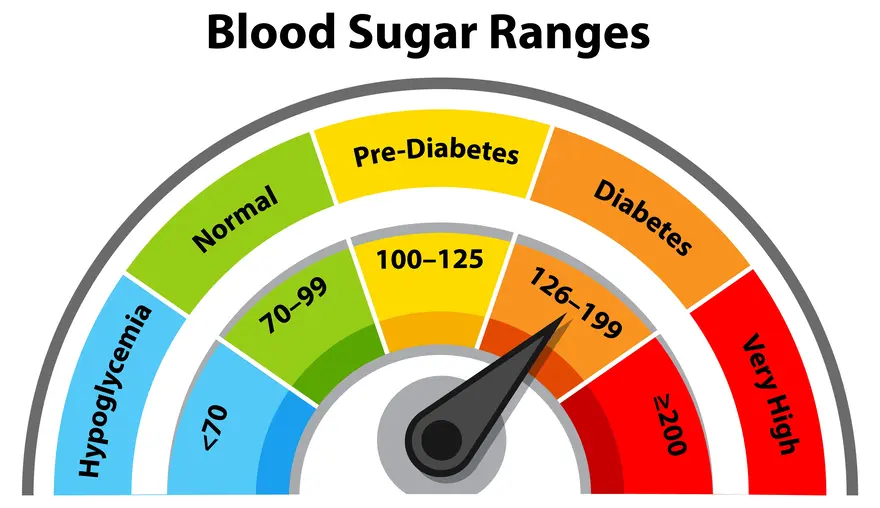

In [39]:
agl = df["avg_glucose_level"].unique()
agl.sort()
agl

array([ 55.12,  55.22,  55.23, ..., 267.61, 267.76, 271.74], shape=(3978,))

In [40]:
def map_avg_glucose_to_health_category(X):
    """
    Discretize average glucose values into ordinal bins based on fixed thresholds.

    This function maps continuous glucose measurements into integer bin indices
    using predefined cut points. It does not perform clipping or normalization.

    Parameters
    ----------
    X : array-like of shape (n_samples,)
        Input average glucose values.

    Returns
    -------
    numpy.ndarray of shape (n_samples,)
        Integer indices representing the bin each glucose value falls into.

    Bin Definition
    --------------
    Bins are defined as:
        [70.0, 99.9, 125.9, 199.9]

    Notes
    -----
    - Uses np.digitize (default: right=False).
    - Values below the first bin return 0.
    - Values above the last bin return len(bins).
    - Output is ordinal and may introduce unintended ordering effects
      in certain models.
    """
    bins = [70.0, 99.9, 125.9, 199.9]   
    # np.digitize returns the index of the bin the value belongs to
    return np.digitize(X, bins)

# feature name out
def glucose_feature_name_out(transformer, input_features):
    return ["glucose_health_category"]

In [41]:
avg_glucose_capper = FunctionTransformer(map_avg_glucose_to_health_category, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('binning_with_cap', avg_glucose_capper)
])

In [42]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('binning_with_cap', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function map...t 0x11b135f80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... 

In [43]:
df[['avg_glucose_level']].head()

,avg_glucose_level
0,228.69
1,202.21
2,105.92
3,171.23
4,174.12


In [44]:
pipe.fit_transform(df[['avg_glucose_level']])[:5]

array([[4],
       [4],
       [2],
       [3],
       [3]])

### **1.1.3 Interaction of age & avg_glocose_level**

In [45]:
def add_age_avg_glucose_interaction(X):
    """
    Create an interaction feature between 'age' and 'avg_glucose_level'.

    This function multiplies the 'age' and 'avg_glucose_level' columns
    to generate a new feature called 'age_glucose_interaction'.

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing 'age' and 'avg_glucose_level' columns.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'age_avg_glucose_interaction'.

    Raises
    ------
    KeyError
        If required columns are not present in the input DataFrame.

    Notes
    -----
    - Assumes input is a pandas DataFrame (typical in ColumnTransformer pipelines).
    - Does not handle missing values; ensure imputation is performed beforehand.
    - Interaction is linear (multiplicative).
    """
    # If X is a DataFrame (which it usually is inside a ColumnTransformer)
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        return (X['age'] * X['avg_glucose_level']).to_frame('age_avg_glucose_interaction')
    else:
        # Assume age is index 0 and glucose is index 1
        interaction = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        return interaction

# feature name out
def age_avg_glucose_interaction_name_out(transformer, input_features):
    return ['age_avg_glucose_interaction']

In [46]:
interaction_feature = FunctionTransformer(add_age_avg_glucose_interaction, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('interaction_pipeline', interaction_feature)
])

In [47]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('interaction_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x11b1367a0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func

In [48]:
pipe.fit_transform(df)[:5]

,age_avg_glucose_interaction
0,15322.23
1,12334.81
2,8473.60
3,8390.27
4,13755.48


### **1.1.4 Interaction of age & bmi**

In [49]:
def add_age_bmi_interaction(X):
    """
    Create an interaction feature between 'age' and 'bmi'.

    This function multiplies the 'age' and 'bmi' columns to generate
    a new feature called 'age_bmi_interaction'.

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing 'age' and 'bmi' columns.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'age_bmi_interaction'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If required columns are missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Interaction is multiplicative (linear interaction term).
    - Intended to be used before ColumnTransformer in a pipeline.
    """
    # If X is a DataFrame (which it usually is inside a ColumnTransformer)
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        return (X['bmi'] * X['age']).to_frame('age_bmi_interaction')
    else:
        # Assume age is index 0 and glucose is index 1
        interaction = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        return interaction
    
# feature name out
def age_bmi_interaction_name_out(tarnsformer, input_fetaure):
    return ['age_bmi_interaction']

In [50]:
interaction_feature = FunctionTransformer(add_age_bmi_interaction, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('interaction_pipeline', interaction_feature)
])

In [51]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('interaction_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x11b136480>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func

In [52]:
pipe.fit_transform(df)[:5]

,age_bmi_interaction
0,2452.2
1,1714.1
2,2600.0
3,1685.6
4,1896.0


### **1.1.5 Ratio of bmi / age**

**bmi_age_ratio = bmi / age**

In [53]:
def bmi_age_ratio(X):
    """
    Create a ratio feature between 'bmi' and 'age'.

    This function computes a new feature 'bmi_age_ratio' defined as:
        bmi / age

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing 'bmi' and 'age' columns.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'bmi_age_ratio'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If required columns are missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Division by zero is handled by replacing zero 'age' values with NaN.
    - This feature captures relative body mass with respect to age,
      which may help models detect health risk patterns.
    - Should be applied before ColumnTransformer in a pipeline.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the ratio column
        X['bmi_age_ratio'] = X['bmi'] / X['age']
        return (X['bmi'] / X['age']).to_frame('bmi_age_ratio')
    else:
        # Assuming age is index 0 and glucose is index 1
        ratio = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        return ratio
    
def bmi_age_ratio_name_out(transformer, input_feature):
    return ['bmi_age_ratio']

In [54]:
ratio_feature = FunctionTransformer(bmi_age_ratio, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('ratio_pipeline', ratio_feature)
])

In [55]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ratio_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function bmi...t 0x11b136340>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... ve

In [56]:
pipe.fit_transform(df)[:5]

,bmi_age_ratio
0,0.546269
1,0.460656
2,0.406250
3,0.702041
4,0.303797


### **1.1.6 Ratio of avg_glucose_level / bmi**

**glucose_bmi_ratio = avg_glucose_level / bmi**

In [57]:
def avg_glucose_bmi_ratio(X):
    """
    Create a ratio feature between 'avg_glucose_level' and 'bmi'.

    This function computes a new feature 'avg_glucose_bmi_ratio' defined as:
        avg_glucose_level / bmi

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing 'avg_glucose_level' and 'bmi' columns.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'avg_glucose_bmi_ratio'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If required columns are missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Division by zero is handled by replacing zero 'bmi' values with NaN.
    - This feature captures relative glucose level with respect to body mass,
      which may help models identify metabolic risk patterns.
    - Should be applied before ColumnTransformer in a pipeline.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        # X['avg_glucose_bmi_ratio'] = X['avg_glucose_level'] / X['bmi']
        return (X['avg_glucose_level'] * X['bmi']).to_frame('avg_glucose_bmi_ratio')
    else:
        # Assuming age is index 0 and glucose is index 1
        ratio = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        return ratio
    
def avg_glucose_bmi_ratio_name_out(transformer, input_feature):
    return ['avg_glucose_bmi_ratio']

In [58]:
ratio_feature = FunctionTransformer(avg_glucose_bmi_ratio, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('ratio_pipeline', ratio_feature)
])

In [59]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ratio_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function avg...t 0x11b136200>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... ve

In [60]:
pipe.fit_transform(df)[:5]

,avg_glucose_bmi_ratio
0,8370.054
1,5682.101
2,3442.400
3,5890.312
4,4178.880


### **1.1.7 Square root of age**

**square_root_of_age = (age)^0.5**

In [61]:
def age_sqrt(X):
    """
    Create a square-root transformed feature of 'age'.

    This function computes a new feature 'age_sqrt' defined as:
        sqrt(age)

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing an 'age' column.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'age_sqrt'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If 'age' column is missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Assumes 'age' values are non-negative (required for sqrt).
    - Square-root transformation can help reduce right skew
      and stabilize variance.
    - Should be applied before ColumnTransformer in a pipeline.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        return (np.sqrt(X['age'])).to_frame('age_sqrt')
    else:
        # Assuming age is index 0
        ratio = (np.sqrt(X[:, 0])).reshape(-1, 1)
        return ratio
    
def age_sqrt_name_out(tranformer, input_fetaure):
    return ['age_sqrt']

In [62]:
sqrt_feature = FunctionTransformer(age_sqrt, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('sqrt_pipeline', sqrt_feature)
])

In [63]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('sqrt_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function age...t 0x11b136980>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... ver

In [64]:
pipe.fit_transform(df)[:5]

,age_sqrt
0,8.185353
1,7.810250
2,8.944272
3,7.000000
4,8.888194


### **1.1.8 Square root of bmi**

**square_root_of_bmi = (bmi)^0.5**

In [65]:
def bmi_sqrt(X):
    """
    Create a square-root transformed feature of 'bmi'.

    This function computes a new feature 'bmi_sqrt' defined as:
        sqrt(bmi)

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing a 'bmi' column.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'bmi_sqrt'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If 'bmi' column is missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Assumes 'bmi' values are non-negative (required for sqrt).
    - Square-root transformation can help reduce right skew
      and stabilize variance.
    - Should be applied before ColumnTransformer in a pipeline.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        return (np.sqrt(X['bmi'])).to_frame('bmi_sqrt')
    else:
        # Assuming age is index 0
        ratio = (np.sqrt(X[:, 0])).reshape(-1, 1)
        return ratio
    
def bmi_sqrt_name_out(tranformer, input_fetaure):
    return ['bmi_sqrt']

In [66]:
sqrt_feature = FunctionTransformer(bmi_sqrt, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('sqrt_pipeline', sqrt_feature)
])

In [67]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('sqrt_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function bmi...t 0x11b136e80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... ver

In [68]:
pipe.fit_transform(df)[:5]

,bmi_sqrt
0,6.049793
1,5.300943
2,5.700877
3,5.865151
4,4.898979


### **1.1.9 Square root of avg_glucose_level**

**square_root_of_avg_glucose_level = (avg_glucose_level)^0.5**

In [69]:
def avg_glucose_level_sqrt(X):
    """
    Create a square-root transformed feature of 'avg_glucose_level'.

    This function computes a new feature 'avg_glucose_level_sqrt' defined as:
        sqrt(avg_glucose_level)

    Parameters
    ----------
    X : pandas.DataFrame
        Input data containing an 'avg_glucose_level' column.

    Returns
    -------
    pandas.DataFrame
        Copy of input DataFrame with an additional column:
        'avg_glucose_level_sqrt'.

    Raises
    ------
    TypeError
        If input is not a pandas DataFrame.
    KeyError
        If 'avg_glucose_level' column is missing.

    Notes
    -----
    - Assumes missing values are handled prior to this step.
    - Assumes 'avg_glucose_level' values are non-negative (required for sqrt).
    - Square-root transformation can help reduce right skew
      and stabilize variance.
    - Should be applied before ColumnTransformer in a pipeline.
    """
    if isinstance(X, pd.DataFrame):
        X = X.copy()
        # Create the interaction column
        return (np.sqrt(X['avg_glucose_level'])).to_frame('avg_glucose_level_sqrt')
    else:
        # Assuming avg glucose level is index 0
        ratio = (np.sqrt(X[:, 0])).reshape(-1, 1)
        return ratio
    
def avg_glucose_level_sqrt_name_out(tranformer, input_fetaure):
    return ['avg_glucose_level_sqrt']

In [70]:
sqrt_feature = FunctionTransformer(avg_glucose_level_sqrt, check_inverse=False)

# 3. Build the Pipeline
pipe = Pipeline([
    ('sqrt_pipeline', sqrt_feature)
])

In [71]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('sqrt_pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function avg...t 0x11b137100>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",False
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... ver

In [72]:
pipe.fit_transform(df)[:5]

,avg_glucose_level_sqrt
0,15.122500
1,14.220056
2,10.291744
3,13.085488
4,13.195454


## 1.2 Feature Transformation

→ modifying existing features (scaling, capping, log)

In [73]:
CAT_FEATURES

['missingindicator_smoking_status']

In [74]:
df[CAT_FEATURES].head()

,missingindicator_smoking_status
0,False
1,False
2,False
3,False
4,False


### 1.2.1 Custom Frequency Encoder

In [75]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Frequency encode categorical features by replacing categories with their
    normalized occurrence frequency.

    This transformer automatically detects categorical columns (object or category dtype)
    and applies frequency encoding to them.

    Parameters
    ----------
    handle_unknown : float, default=0.0
        Value to assign to unseen categories during transform.

    Attributes
    ----------
    freq_maps_ : dict
        Dictionary mapping column names to frequency mappings.
    columns_ : list
        List of columns that were encoded.
    """

    def __init__(self, handle_unknown=0.0):
        self.handle_unknown = handle_unknown

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        # Store column names exactly as received
        self.columns_ = X.columns.tolist()
        self.freq_maps_ = {}

        for col in self.columns_:
            freq = X[col].value_counts(normalize=True)
            self.freq_maps_[col] = freq

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in self.columns_:
            X[col] = X[col].map(self.freq_maps_[col]).fillna(self.handle_unknown)

        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.columns_

        return [f"{col}_freq" for col in input_features]

In [76]:
freq_encoder = ColumnTransformer(
    transformers=[
        ( 'freq_encoder', FrequencyEncoder(), CAT_FEATURES)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

In [77]:
df = schema_correction_pipeline.fit_transform(df)
df = missing_imputation_pipeline.fit_transform(df)

In [78]:
freq_encoder.fit_transform(df)[:5]

,missingindicator_smoking_status_freq,gender,ever_married,work_type,residence_type,smoking_status,age,bmi,avg_glucose_level,missingindicator_bmi,id,hypertension,heart_disease,stroke
0,0.697788,male,yes,private,urban,formerly_smoked,67.0,36.6,228.69,0.0,9046,0,1,1
1,0.697788,female,yes,self_employed,rural,never_smoked,61.0,28.1,202.21,1.0,51676,0,0,1
2,0.697788,male,yes,private,rural,never_smoked,80.0,32.5,105.92,0.0,31112,0,1,1
3,0.697788,female,yes,private,urban,smokes,49.0,34.4,171.23,0.0,60182,0,0,1
4,0.697788,female,yes,self_employed,rural,never_smoked,79.0,24.0,174.12,0.0,1665,1,0,1


## 1.3 Handling Numerical Feature

In [79]:
NUM_FEATURES

['gender',
 'ever_married',
 'work_type',
 'residence_type',
 'smoking_status',
 'age',
 'bmi',
 'avg_glucose_level',
 'missingindicator_bmi',
 'hypertension',
 'heart_disease']

In [80]:
df[NUM_FEATURES].head()

,gender,ever_married,work_type,residence_type,smoking_status,age,bmi,avg_glucose_level,missingindicator_bmi,hypertension,heart_disease
0,male,yes,private,urban,formerly_smoked,67.0,36.6,228.69,0.0,0,1
1,female,yes,self_employed,rural,never_smoked,61.0,28.1,202.21,1.0,0,0
2,male,yes,private,rural,never_smoked,80.0,32.5,105.92,0.0,0,1
3,female,yes,private,urban,smokes,49.0,34.4,171.23,0.0,0,0
4,female,yes,self_employed,rural,never_smoked,79.0,24.0,174.12,0.0,1,0


In [81]:
# df = pipeline.fit_transform(df)

### **1.3.1 Age**

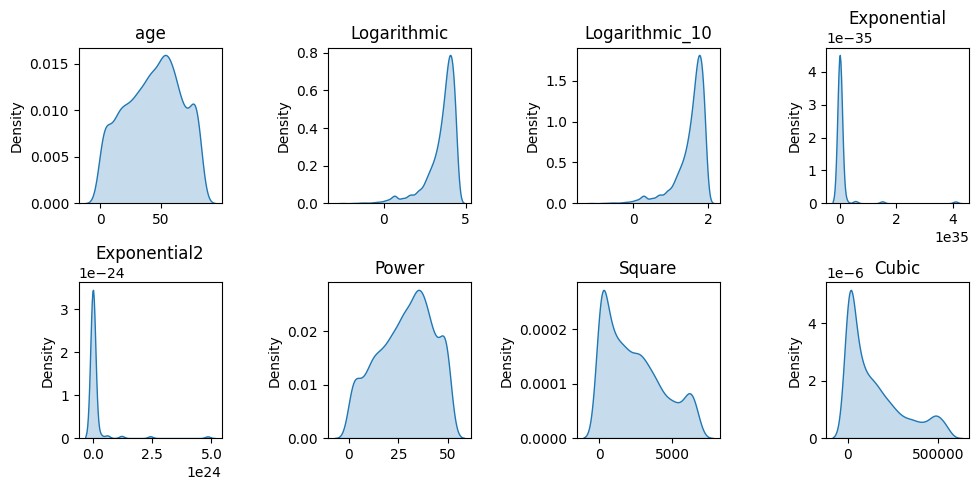

In [82]:
column = 'age'
# loading data in encoding object
trans_feature = DataEncoding(df[[column]])
# performing all scaline
trans_feature.transform_with_all_technique(column)
trans_feature.plot_all_combinations(trans_feature.df)

**Action:**

- None

### **1.3.2 Avg_glucose_level**

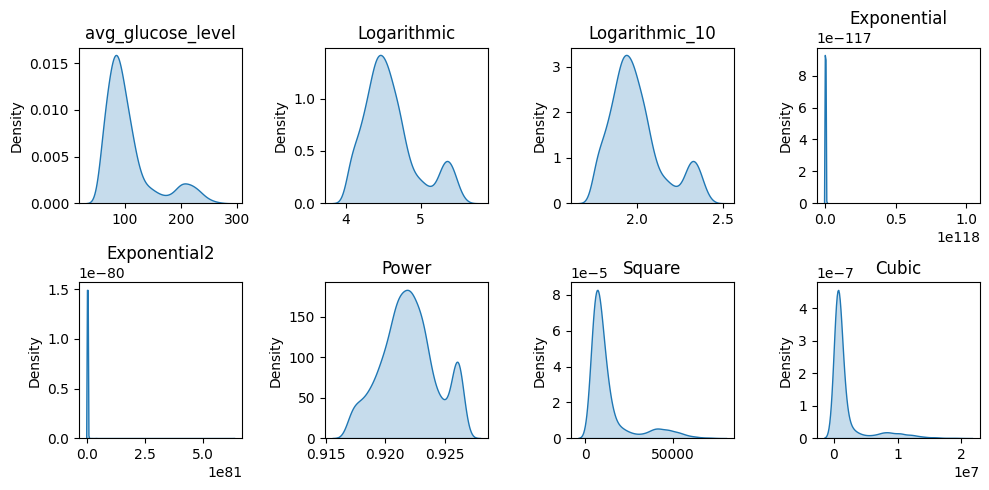

In [83]:
column = 'avg_glucose_level'
# loading data in encoding object
trans_feature = DataEncoding(df[[column]])
# performing all scaline
trans_feature.transform_with_all_technique(column)
trans_feature.plot_all_combinations(trans_feature.df)

**Action:**

- Power Transformation

### **1.3.3 Bmi**

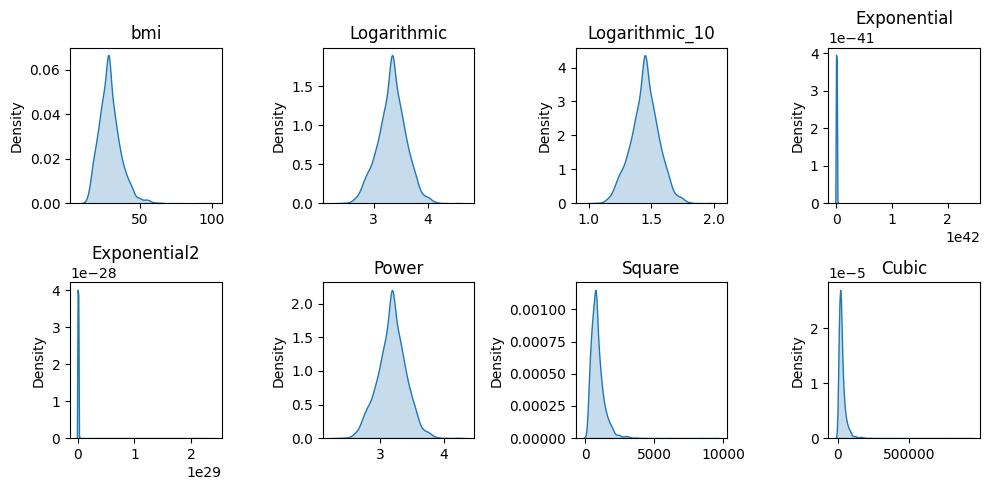

In [84]:
column = 'bmi'
# loading data in encoding object
trans_feature = DataEncoding(df[[column]])
# performing all scaline
trans_feature.transform_with_all_technique(column)
trans_feature.plot_all_combinations(trans_feature.df)

**Action:**

- Power Transformtion

### Numerical Pipeline

In [85]:
from sklearn.preprocessing import PowerTransformer

In [86]:
num_scaler = ColumnTransformer(
    transformers=[
        ('num_transform', PowerTransformer(method='yeo-johnson'), ['avg_glucose_level', 'bmi'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [87]:
num_scaler

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g

In [88]:
pd.DataFrame(num_scaler.fit_transform(df[NUM_FEATURES]),columns=num_scaler.get_feature_names_out().tolist()).head()

,avg_glucose_level,bmi,gender,ever_married,work_type,residence_type,smoking_status,age,missingindicator_bmi,hypertension,heart_disease
0,1.862392,1.045197,male,yes,private,urban,formerly_smoked,67.0,0.0,0,1
1,1.700511,0.026753,female,yes,self_employed,rural,never_smoked,61.0,1.0,0,0
2,0.395031,0.587449,male,yes,private,rural,never_smoked,80.0,0.0,0,1
3,1.445120,0.806387,female,yes,private,urban,smokes,49.0,0.0,0,0
4,1.472918,-0.580998,female,yes,self_employed,rural,never_smoked,79.0,0.0,1,0


## 1.4 Handeling Date Feature

In [89]:
# don't have date related columns

## 1.5 Handeling Text Feature

In [90]:
# don't have text related columns

## 2.1 Scaling & Transformation

## Merge Pipelines

In [91]:
from heart_stroke_prediction.analyze.data_correction.schema_correction import MissingValueNormalizer, ColumnNameCorrector, ValueCorrector, FrequencyFilter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

from sklearn import set_config
# Set global configuration to output Pandas DataFrames
set_config(transform_output="pandas")

In [92]:
NUM_FEATURES, CAT_FEATURES, ALREADY_PROCESSED

(['gender',
  'ever_married',
  'work_type',
  'residence_type',
  'smoking_status',
  'age',
  'bmi',
  'avg_glucose_level',
  'missingindicator_bmi',
  'hypertension',
  'heart_disease'],
 ['missingindicator_smoking_status'],
 ['hypertension', 'heart_disease'])

In [93]:
df = pd.read_csv(DATA_FILE_NAME['raw'])
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### **1. Data Cleaning Pipeline**

In [94]:
column_correction_dict = {
    'Residence_type': 'residence_type'
}
value_correction_dict = {
    'gender': {'Male': 'male', 'Female': 'female', 'Other': 'other'},
    'ever_married': {'Yes':'yes', 'No': 'no'},
    'residence_type': {'Urban': 'urban', 'Rural': 'rural'},
    'smoking_status': {'formerly smoked': 'formerly_smoked', 
                            'never smoked': 'never_smoked', 
                            'Unknown': 'unknown'},
    'work_type': {'Private':'private', 'self-employed': 'self_employed', 
                            'Govt_job': 'govt_job', 'Never_worked': 'never_worked',
                            'children': 'children'},
}

In [95]:
static_data_correction_pipeline = Pipeline(
                    steps=[
                        ('correct_column_names', ColumnNameCorrector(mapping=column_correction_dict)),
                        ('correct_column_values', ValueCorrector(column_mappings=value_correction_dict)),
                        ('missing_normalizer', MissingValueNormalizer(missing_tokens=['unknown'])),
                        ('frequency_filter', FrequencyFilter(threshold=1, action='drop')),
                    ]
                )

In [96]:
static_data_correction_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,threshold,1
,action,'drop'
,fill_value,'other'


In [97]:
df_composed = static_data_correction_pipeline.fit_transform(df)
df_composed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [98]:
df_composed.shape

(5109, 12)

In [99]:
df_composed.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,female,80.0,1,0,yes,private,urban,83.75,NaN,never_smoked,0
5106,44873,female,81.0,0,0,yes,self_employed,urban,125.20,40.0,never_smoked,0
5107,19723,female,35.0,0,0,yes,self_employed,rural,82.99,30.6,never_smoked,0
5108,37544,male,51.0,0,0,yes,private,rural,166.29,25.6,formerly_smoked,0
5109,44679,female,44.0,0,0,yes,govt_job,urban,85.28,26.2,NaN,0


### **2. Impute Missing Pipeline**

In [100]:
missing_categorical_pipeline = Pipeline(
    steps=[
        # handle missing
        ('cat_imputer', SimpleImputer(strategy="constant", missing_values=np.nan, fill_value='missing', add_indicator=True)),
        # encode features
        # ("onehot_encoder", OneHotEncoder(
        #                     drop='first',
        #                     sparse_output=False,
        #                     handle_unknown='ignore',
        #                     min_frequency=1,
        #                 )),
    ]
)

missing_numerical_pipeline = Pipeline(
    steps=[
        # handle missing
        ('num_imputer', SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

In [101]:
NUM_FEATURES

['gender',
 'ever_married',
 'work_type',
 'residence_type',
 'smoking_status',
 'age',
 'bmi',
 'avg_glucose_level',
 'missingindicator_bmi',
 'hypertension',
 'heart_disease']

In [102]:
CAT_FEATURES

['missingindicator_smoking_status']

In [103]:
NOMINAL_CAT_FEATURES = ['work_type', 'smoking_status']
BINARY_CAT_FEATURES = ['gender', 'ever_married', 'residence_type']

In [104]:
pipeline = Pipeline([('impute_missing', ColumnTransformer(
                                    transformers=[
                                        # ('drop_columns', 'drop', ID_COL+TARGET_COL),
                                        ('cat', missing_categorical_pipeline, NOMINAL_CAT_FEATURES + BINARY_CAT_FEATURES),
                                        ('num', missing_numerical_pipeline, ['bmi']),
                                    ],
                                    remainder='passthrough',
                                    verbose_feature_names_out=False,
                                )
                            )])

In [105]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [106]:
df_composed = pipeline.fit_transform(df_composed)
df_composed.head()

,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,bmi,missingindicator_bmi,id,age,hypertension,heart_disease,avg_glucose_level,stroke
0,private,formerly_smoked,male,yes,urban,False,36.6,0.0,9046,67.0,0,1,228.69,1
1,self_employed,never_smoked,female,yes,rural,False,28.1,1.0,51676,61.0,0,0,202.21,1
2,private,never_smoked,male,yes,rural,False,32.5,0.0,31112,80.0,0,1,105.92,1
3,private,smokes,female,yes,urban,False,34.4,0.0,60182,49.0,0,0,171.23,1
4,self_employed,never_smoked,female,yes,rural,False,24.0,0.0,1665,79.0,1,0,174.12,1


In [107]:
df_composed.info()

<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   work_type                        5109 non-null   str    
 1   smoking_status                   5109 non-null   str    
 2   gender                           5109 non-null   str    
 3   ever_married                     5109 non-null   str    
 4   residence_type                   5109 non-null   str    
 5   missingindicator_smoking_status  5109 non-null   object 
 6   bmi                              5109 non-null   float64
 7   missingindicator_bmi             5109 non-null   float64
 8   id                               5109 non-null   int64  
 9   age                              5109 non-null   float64
 10  hypertension                     5109 non-null   int64  
 11  heart_disease                    5109 non-null   int64  
 12  avg_glucose_level                510

In [108]:
df_composed.tail()

,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,bmi,missingindicator_bmi,id,age,hypertension,heart_disease,avg_glucose_level,stroke
5105,private,never_smoked,female,yes,urban,False,28.1,1.0,18234,80.0,1,0,83.75,0
5106,self_employed,never_smoked,female,yes,urban,False,40.0,0.0,44873,81.0,0,0,125.20,0
5107,self_employed,never_smoked,female,yes,rural,False,30.6,0.0,19723,35.0,0,0,82.99,0
5108,private,formerly_smoked,male,yes,rural,False,25.6,0.0,37544,51.0,0,0,166.29,0
5109,govt_job,missing,female,yes,urban,True,26.2,0.0,44679,44.0,0,0,85.28,0


In [109]:
df_composed.isna().sum()

work_type                          0
smoking_status                     0
gender                             0
ever_married                       0
residence_type                     0
missingindicator_smoking_status    0
bmi                                0
missingindicator_bmi               0
id                                 0
age                                0
hypertension                       0
heart_disease                      0
avg_glucose_level                  0
stroke                             0
dtype: int64

### **3. Feature Extraction Pipeline**

In [110]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [114]:
# def naming_bmi_cap(transformer, input_features):
#     # 'input_features' will be ['a', 'b'] because it's coming from the DataFrame
#     return ["bmi_cap"]

# def naming_glucose_cap(transformer, input_features):
#     # 'input_features' will be ['a', 'b'] because it's coming from the DataFrame
#     return ["avg_glucose_level_cap"]

# def apply_bmi_caps_and_bins(X): 
#     bins = [16.0, 17.0, 18.5, 25.0, 30.0, 35.0, 40.0] 
#     # np.digitize returns the index of the bin the value belongs to
#     return np.digitize(X, bins)

# def apply_avg_glucose_caps_and_bins(X): 
#     bins = [70.0, 99.9, 125.9, 199.9] 
#     # np.digitize returns the index of the bin the value belongs to
#     return np.digitize(X, bins)

# def create_interaction(X):
#     # If X is a DataFrame (which it usually is inside a ColumnTransformer)
#     if isinstance(X, pd.DataFrame):
#         X = X.copy()
#         # Create the interaction column
#         return (X['age'] * X['avg_glucose_level']).to_frame('age_glucose')
#     else:
#         # Assuming age is index 0 and glucose is index 1
#         interaction = (X[:, 0] * X[:, 1]).reshape(-1, 1)
#         return interaction

# def interaction_age_glucose(transformer, input_features):
#     return ['age_glucose']

# def create_interaction1(X):
#     # If X is a DataFrame (which it usually is inside a ColumnTransformer)
#     if isinstance(X, pd.DataFrame):
#         X = X.copy()
#         # Create the interaction column
#         return (X['age'] * X['bmi']).to_frame('age_bmi')
    
# def interaction_age_bmi(transformer, input_features):
#     return ['age_bmi']


In [111]:
pipeline.steps.append(
    ('feature_extraction',
     ColumnTransformer(
            transformers=[
                ('cap_bmi', FunctionTransformer(map_bmi_to_health_category, feature_names_out=bmi_feature_name_out), ['bmi']),
                ('cap_avg_glucose_level', FunctionTransformer(map_avg_glucose_to_health_category, feature_names_out=glucose_feature_name_out), ['avg_glucose_level']),
                ('inter_age_avg_glucose', FunctionTransformer(add_age_avg_glucose_interaction, feature_names_out=age_avg_glucose_interaction_name_out), ['age', 'avg_glucose_level']),
                ('inter_age_bmi', FunctionTransformer(add_age_bmi_interaction, feature_names_out=age_bmi_interaction_name_out), ['age', 'bmi']),
                ('ratio_bmi_age', FunctionTransformer(bmi_age_ratio, feature_names_out=bmi_age_ratio_name_out), ['bmi', 'age']),
                ('ratio_avg_glucose_bmi', FunctionTransformer(avg_glucose_bmi_ratio, feature_names_out=avg_glucose_bmi_ratio_name_out), ['avg_glucose_level', 'bmi']),
                ('sqrt_age', FunctionTransformer(age_sqrt, feature_names_out=age_sqrt_name_out), ['age']),
                ('sqrt_bmi', FunctionTransformer(bmi_sqrt, feature_names_out=bmi_sqrt_name_out), ['bmi']),
                ('sqrt_avg_glucose_level', FunctionTransformer(avg_glucose_level_sqrt, feature_names_out=avg_glucose_level_sqrt_name_out), ['avg_glucose_level']),
                ('cat', 'passthrough', ALREADY_PROCESSED),
                ('num', 'passthrough', ['age', 'bmi', 'avg_glucose_level']),
            ],
            remainder='passthrough',
            verbose_feature_names_out=False,
        )
     )
    )

In [112]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [113]:
df_composed = static_data_correction_pipeline.fit_transform(df)
df_composed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [114]:
df_composed = pipeline.fit_transform(df_composed)
df_composed.head()

,bmi_health_category,glucose_health_category,age_avg_glucose_interaction,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,avg_glucose_level_sqrt,hypertension,...,avg_glucose_level,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,missingindicator_bmi,id,stroke
0,6,4,15322.23,2452.2,0.546269,8370.054,8.185353,6.049793,15.122500,0,...,228.69,private,formerly_smoked,male,yes,urban,False,0.0,9046,1
1,4,4,12334.81,1714.1,0.460656,5682.101,7.810250,5.300943,14.220056,0,...,202.21,self_employed,never_smoked,female,yes,rural,False,1.0,51676,1
2,5,2,8473.60,2600.0,0.406250,3442.400,8.944272,5.700877,10.291744,0,...,105.92,private,never_smoked,male,yes,rural,False,0.0,31112,1
3,5,3,8390.27,1685.6,0.702041,5890.312,7.000000,5.865151,13.085488,0,...,171.23,private,smokes,female,yes,urban,False,0.0,60182,1
4,3,3,13755.48,1896.0,0.303797,4178.880,8.888194,4.898979,13.195454,1,...,174.12,self_employed,never_smoked,female,yes,rural,False,0.0,1665,1


In [115]:
df_composed.tail()

,bmi_health_category,glucose_health_category,age_avg_glucose_interaction,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,avg_glucose_level_sqrt,hypertension,...,avg_glucose_level,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,missingindicator_bmi,id,stroke
5105,4,1,6700.00,2248.0,0.351250,2353.375,8.944272,5.300943,9.151503,1,...,83.75,private,never_smoked,female,yes,urban,False,1.0,18234,0
5106,7,2,10141.20,3240.0,0.493827,5008.000,9.000000,6.324555,11.189281,0,...,125.20,self_employed,never_smoked,female,yes,urban,False,0.0,44873,0
5107,5,1,2904.65,1071.0,0.874286,2539.494,5.916080,5.531727,9.109885,0,...,82.99,self_employed,never_smoked,female,yes,rural,False,0.0,19723,0
5108,4,3,8480.79,1305.6,0.501961,4257.024,7.141428,5.059644,12.895348,0,...,166.29,private,formerly_smoked,male,yes,rural,False,0.0,37544,0
5109,4,1,3752.32,1152.8,0.595455,2234.336,6.633250,5.118594,9.234717,0,...,85.28,govt_job,missing,female,yes,urban,True,0.0,44679,0


In [116]:
df_composed.isna().sum()

bmi_health_category                0
glucose_health_category            0
age_avg_glucose_interaction        0
age_bmi_interaction                0
bmi_age_ratio                      0
avg_glucose_bmi_ratio              0
age_sqrt                           0
bmi_sqrt                           0
avg_glucose_level_sqrt             0
hypertension                       0
heart_disease                      0
age                                0
bmi                                0
avg_glucose_level                  0
work_type                          0
smoking_status                     0
gender                             0
ever_married                       0
residence_type                     0
missingindicator_smoking_status    0
missingindicator_bmi               0
id                                 0
stroke                             0
dtype: int64

In [117]:
df_composed.shape

(5109, 23)

### **4. Outlier Handler Pipeline**

In [118]:
from sklearn.preprocessing import QuantileTransformer

In [119]:
df_composed = static_data_correction_pipeline.fit_transform(df)
df_composed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [120]:
outlier_handler = ColumnTransformer(
            transformers=[
                (
                    'power_transform',
                    PowerTransformer(method='yeo-johnson'),
                    ['bmi']
                ),
                (
                    'quantile_transform',
                    QuantileTransformer(n_quantiles=100, output_distribution='normal'),
                    ['avg_glucose_level']
                ),
                ('drop', 'drop', ['id', 'stroke']),
            ], 
            remainder='passthrough',
            verbose_feature_names_out=False
        )

In [121]:
# outlier_handler = ColumnTransformer(
#                     transformers=[
#                         # handle outliers
#                         (
#                          'outlier_handler',
#                         #  PowerTransformer(method='yeo-johnson'),
#                         QuantileTransformer(n_quantiles=100, output_distribution='normal'),
#                          ['bmi', 'avg_glucose_level']
#                          ),
#                         ('drop', 'drop', ['id', 'stroke']),
#                     ],
#                     remainder='passthrough',
#                     verbose_feature_names_out=False
#                 )

In [122]:
pipeline.steps.append(('outlier_handeling', outlier_handler))

In [123]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [128]:
df_composed = pipeline.fit_transform(df_composed)
df_composed.head()

,bmi,avg_glucose_level,bmi_health_category,glucose_health_category,age_avg_glucose_interaction,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,...,hypertension,heart_disease,age,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,missingindicator_bmi
0,1.045197,1.936400,6,4,15322.23,2452.2,0.546269,8370.054,8.185353,6.049793,...,0,1,67.0,private,formerly_smoked,male,yes,urban,False,0.0
1,0.026753,1.408310,4,4,12334.81,1714.1,0.460656,5682.101,7.810250,5.300943,...,0,0,61.0,self_employed,never_smoked,female,yes,rural,False,1.0
2,0.587449,0.457204,5,2,8473.60,2600.0,0.406250,3442.400,8.944272,5.700877,...,0,1,80.0,private,never_smoked,male,yes,rural,False,0.0
3,0.806387,1.171189,5,3,8390.27,1685.6,0.702041,5890.312,7.000000,5.865151,...,0,0,49.0,private,smokes,female,yes,urban,False,0.0
4,-0.580998,1.183019,3,3,13755.48,1896.0,0.303797,4178.880,8.888194,4.898979,...,1,0,79.0,self_employed,never_smoked,female,yes,rural,False,0.0


In [129]:
df_composed.tail()

,bmi,avg_glucose_level,bmi_health_category,glucose_health_category,age_avg_glucose_interaction,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,...,hypertension,heart_disease,age,work_type,smoking_status,gender,ever_married,residence_type,missingindicator_smoking_status,missingindicator_bmi
5105,0.026753,-0.339284,4,1,6700.00,2248.0,0.351250,2353.375,8.944272,5.300943,...,1,0,80.0,private,never_smoked,female,yes,urban,False,1.0
5106,1.387221,0.857802,7,2,10141.20,3240.0,0.493827,5008.000,9.000000,6.324555,...,0,0,81.0,self_employed,never_smoked,female,yes,urban,False,0.0
5107,0.355274,-0.376616,5,1,2904.65,1071.0,0.874286,2539.494,5.916080,5.531727,...,0,0,35.0,self_employed,never_smoked,female,yes,rural,False,0.0
5108,-0.332352,1.149177,4,3,8480.79,1305.6,0.501961,4257.024,7.141428,5.059644,...,0,0,51.0,private,formerly_smoked,male,yes,rural,False,0.0
5109,-0.243076,-0.264187,4,1,3752.32,1152.8,0.595455,2234.336,6.633250,5.118594,...,0,0,44.0,govt_job,missing,female,yes,urban,True,0.0


### **5. OneHot Encode Pipeline**

In [130]:
encoder = OneHotEncoder(
                    sparse_output=False, 
                    min_frequency=5,
                    handle_unknown='ignore',
                    drop='if_binary',
                    dtype=np.float64
                )

In [131]:
encode_transformer = ColumnTransformer(
            transformers=[
                ('encode_cat', encoder, ['gender', 'ever_married', 'residence_type', 'work_type', 'smoking_status', 'missingindicator_smoking_status']),
            ],
            remainder='passthrough',
            verbose_feature_names_out=False,
        )

In [132]:
encode_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [133]:
pipeline.steps.append(('encoding', encode_transformer))

In [134]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [135]:
df_composed.isna().sum()

bmi                                0
avg_glucose_level                  0
bmi_health_category                0
glucose_health_category            0
age_avg_glucose_interaction        0
age_bmi_interaction                0
bmi_age_ratio                      0
avg_glucose_bmi_ratio              0
age_sqrt                           0
bmi_sqrt                           0
avg_glucose_level_sqrt             0
hypertension                       0
heart_disease                      0
age                                0
work_type                          0
smoking_status                     0
gender                             0
ever_married                       0
residence_type                     0
missingindicator_smoking_status    0
missingindicator_bmi               0
dtype: int64

In [136]:
df_composed = static_data_correction_pipeline.fit_transform(df)
df_composed.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


In [137]:
df_composed = pipeline.fit_transform(df_composed)
df_composed.head()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,...,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,avg_glucose_level_sqrt,hypertension,heart_disease,age,missingindicator_bmi
0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,2452.2,0.546269,8370.054,8.185353,6.049793,15.122500,0,1,67.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1714.1,0.460656,5682.101,7.810250,5.300943,14.220056,0,0,61.0,1.0
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2600.0,0.406250,3442.400,8.944272,5.700877,10.291744,0,1,80.0,0.0
3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1685.6,0.702041,5890.312,7.000000,5.865151,13.085488,0,0,49.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1896.0,0.303797,4178.880,8.888194,4.898979,13.195454,1,0,79.0,0.0


In [138]:
df_composed.tail()

,gender_male,ever_married_yes,residence_type_urban,work_type_children,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,smoking_status_formerly_smoked,smoking_status_missing,...,age_bmi_interaction,bmi_age_ratio,avg_glucose_bmi_ratio,age_sqrt,bmi_sqrt,avg_glucose_level_sqrt,hypertension,heart_disease,age,missingindicator_bmi
5105,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2248.0,0.351250,2353.375,8.944272,5.300943,9.151503,1,0,80.0,1.0
5106,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3240.0,0.493827,5008.000,9.000000,6.324555,11.189281,0,0,81.0,0.0
5107,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1071.0,0.874286,2539.494,5.916080,5.531727,9.109885,0,0,35.0,0.0
5108,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1305.6,0.501961,4257.024,7.141428,5.059644,12.895348,0,0,51.0,0.0
5109,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1152.8,0.595455,2234.336,6.633250,5.118594,9.234717,0,0,44.0,0.0


In [139]:
df.shape, df_composed.shape

((5110, 12), (5109, 28))

In [140]:
# df_composed[TARGET_COL] = df[TARGET_COL]

In [ ]:
# df_composed.to_csv(DATA_FILE_NAME['engineered'], index=False)

## 2.4 Handeling Imbalanced Data

In [142]:
from sklearn.compose import ColumnTransformer # columns
from sklearn.pipeline import Pipeline  # pipeline

# handling imabalnced data
from imblearn.pipeline import Pipeline as ImbPipeline

# cross validation
from sklearn.model_selection import StratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
df = static_data_correction_pipeline.fit_transform(pd.read_csv(DATA_FILE_NAME['raw']))

In [144]:
# X = df.drop(TARGET_COL+ID_COL, axis=1)
y = df[TARGET_COL]

In [145]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,NaN,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


#### Model With Imbalanced Data

In [146]:
rng = np.random.default_rng()

In [147]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [148]:
preprocessor = pipeline

In [149]:
# preprocessor.steps

In [150]:
# preprocessor.steps

In [151]:
model_pipeline = ImbPipeline(
    steps=preprocessor.steps+[
        ('scaler', RobustScaler()),
        # ('smote', SMOTEENN(random_state=42,sampling_strategy='minority')),
        ('model', BalancedRandomForestClassifier(
            random_state=42,
            sampling_strategy='majority',
            # sampling_strategy=0.44840529667811524
            ))
    ]
)

In [152]:
model_pipeline

,steps,"[('impute_missing', ...), ('feature_extraction', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string rea

In [153]:
# model_pipeline.steps

In [154]:
# model_pipeline.fit(X, y)

In [155]:
import numpy as np
from sklearn.metrics import average_precision_score


def recall_at_percent(y_true, y_scores, percent):
    n = len(y_true)
    k = int(np.ceil(n * percent))

    indices = np.argsort(y_scores)[::-1]
    top_k = indices[:k]

    return y_true[top_k].sum() / y_true.sum()


def precision_at_percent(y_true, y_scores, percent):
    n = len(y_true)
    k = int(np.ceil(n * percent))

    indices = np.argsort(y_scores)[::-1]
    top_k = indices[:k]

    return y_true[top_k].sum() / k


def nns_at_percent(y_true, y_scores, percent):
    precision = precision_at_percent(y_true, y_scores, percent)
    if precision == 0:
        return np.inf
    return 1 / precision


In [156]:
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=41)

metrics = {
    "roc_auc": [],
    "pr_auc": [],
    "recall_10": [],
    "recall_15": [],
    "recall_20": [],
    "precision_10": [],
    "nns_10": []
}

for train_idx, test_idx in cv.split(df, y):
    X_train, X_test = df.iloc[train_idx], df.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_pipeline.fit(X_train, y_train)
    y_scores = model_pipeline.predict_proba(X_test)[:, 1]

    # Core metrics
    metrics["roc_auc"].append(roc_auc_score(y_test, y_scores))
    metrics["pr_auc"].append(average_precision_score(y_test, y_scores))

    # Ranking metrics
    metrics["recall_10"].append(recall_at_percent(y_test.values, y_scores, 0.10))
    metrics["recall_15"].append(recall_at_percent(y_test.values, y_scores, 0.15))
    metrics["recall_20"].append(recall_at_percent(y_test.values, y_scores, 0.20))

    metrics["precision_10"].append(precision_at_percent(y_test.values, y_scores, 0.10))
    metrics["nns_10"].append(nns_at_percent(y_test.values, y_scores, 0.10))
    

In [157]:
for key, values in metrics.items():
    print(f"{key}: {np.mean(values):.4f} ({np.std(values):.4f})")

roc_auc: 0.8297 (0.0266)
pr_auc: 0.1820 (0.0405)
recall_10: 0.4096 (0.0671)
recall_15: 0.5300 (0.0587)
recall_20: 0.6425 (0.0498)
precision_10: 0.1981 (0.0328)
nns_10: 5.1661 (0.7085)


In [158]:
from sklearn.calibration import CalibratedClassifierCV

metrics = {
    "roc_auc": [],
    "pr_auc": [],
    "recall_10": [],
    "recall_15": [],
    "recall_20": [],
    "precision_10": [],
    "nns_10": []
}

for train_idx, test_idx in cv.split(df, y):
    X_train, X_test = df.iloc[train_idx], df.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    calibrated_model = CalibratedClassifierCV(
        estimator=model_pipeline,
        method="sigmoid",
        cv=3
    )

    calibrated_model.fit(X_train, y_train)

    y_scores = calibrated_model.predict_proba(X_test)[:, 1]

    # Core metrics
    metrics["roc_auc"].append(roc_auc_score(y_test, y_scores))
    metrics["pr_auc"].append(average_precision_score(y_test, y_scores))

    # Ranking metrics
    metrics["recall_10"].append(recall_at_percent(y_test.values, y_scores, 0.10))
    metrics["recall_15"].append(recall_at_percent(y_test.values, y_scores, 0.15))
    metrics["recall_20"].append(recall_at_percent(y_test.values, y_scores, 0.20))

    metrics["precision_10"].append(precision_at_percent(y_test.values, y_scores, 0.10))
    metrics["nns_10"].append(nns_at_percent(y_test.values, y_scores, 0.10))

In [159]:
for key, values in metrics.items():
    print(f"{key}: {np.mean(values):.4f} ({np.std(values):.4f})")

roc_auc: 0.8357 (0.0278)
pr_auc: 0.1891 (0.0442)
recall_10: 0.4175 (0.0742)
recall_15: 0.5702 (0.0593)
recall_20: 0.6504 (0.0610)
precision_10: 0.2019 (0.0365)
nns_10: 5.0898 (0.7662)


- Probability calibration improved PR-AUC and mid-percentile recall while preserving top-decile screening efficiency, indicating enhanced probability reliability without loss of ranking performance.

## Cross-Validated Brier Score

In [160]:
import numpy as np
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import StratifiedKFold

def cross_validated_brier(model, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=41)
    scores = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_probs = model.predict_proba(X_test)[:, 1]

        score = brier_score_loss(y_test, y_probs)
        scores.append(score)

    return np.mean(scores), np.std(scores)

In [161]:
mean_brier, std_brier = cross_validated_brier(calibrated_model, df, y)

print(f"Brier Score: {mean_brier:.4f} ({std_brier:.4f})")

Brier Score: 0.0427 (0.0009)


## Cross-Validated Calibration Curve

In [162]:
from sklearn.calibration import calibration_curve

def plot_cv_calibration(model, X, y, n_splits=5, n_bins=10):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=41)

    all_probs = []
    all_true = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_probs = model.predict_proba(X_test)[:, 1]

        all_probs.extend(y_probs)
        all_true.extend(y_test)

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    prob_true, prob_pred = calibration_curve(
        all_true, all_probs, n_bins=n_bins
    )

    plt.figure()
    plt.plot(prob_pred, prob_true)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Probability")
    plt.title("Cross-Validated Calibration Curve")
    plt.show()

In [163]:
def plot_cv_calibration(model, X, y, n_splits=5, n_bins=10):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=41)

    all_probs = np.zeros(len(y))
    all_true = np.array(y)

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]

        # Store predictions in correct original index positions
        all_probs[test_idx] = probs

    prob_true, prob_pred = calibration_curve(
        all_true,
        all_probs,
        n_bins=n_bins,
        strategy="uniform"
    )

    plt.figure()
    plt.plot(prob_pred, prob_true)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Probability")
    plt.title("Cross-Validated Calibration Curve")
    plt.show()

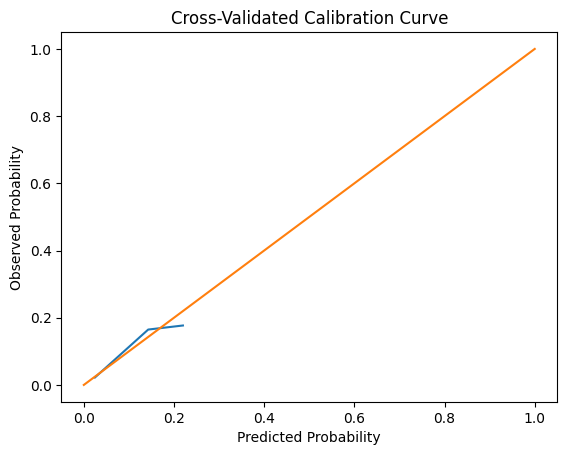

In [164]:
plot_cv_calibration(calibrated_model, df, y)

### Before vs After Calibration Comparison

In [165]:
print("Uncalibrated:")
print(cross_validated_brier(model_pipeline, df, y))

print("Calibrated:")
print(cross_validated_brier(calibrated_model, df, y))


Uncalibrated:
(np.float64(0.18259117750334944), np.float64(0.01127092339107131))
Calibrated:
(np.float64(0.042655588227355094), np.float64(0.0009482655881275428))


### Calibration Plot

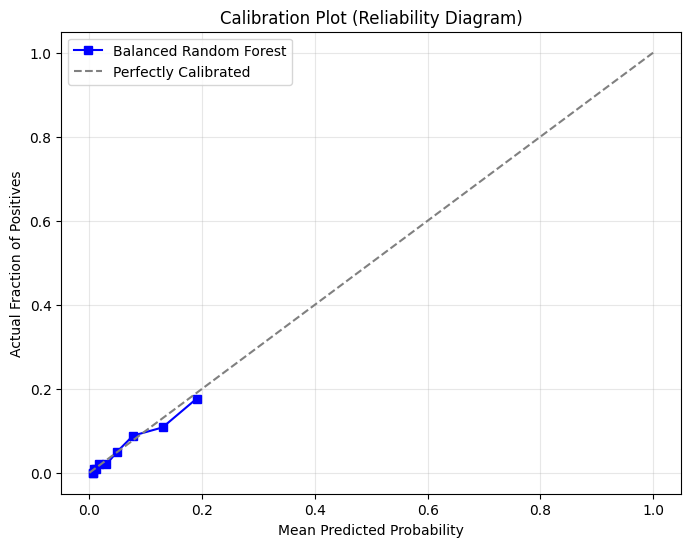

In [166]:

calibrated_model = CalibratedClassifierCV(
    estimator=model_pipeline,
    method="sigmoid",
    cv=3
)

calibrated_model.fit(X_train, y_train)

# 1. Get predicted probabilities for the test set
y_probs = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Calculate calibration points (using 10 bins)
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10, strategy='quantile')

# 3. Visualization
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='s', label='Balanced Random Forest', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Fraction of Positives')
plt.title('Calibration Plot (Reliability Diagram)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [167]:
prob_true, prob_pred

(array([0.        , 0.        , 0.00990099, 0.00980392, 0.01960784,
        0.01960784, 0.04901961, 0.08823529, 0.10784314, 0.17647059]),
 array([0.00564393, 0.00608374, 0.007531  , 0.01099949, 0.01756336,
        0.03003942, 0.04830753, 0.07728666, 0.12965065, 0.19021874]))

## Save feature engineering pipeline

In [168]:
import cloudpickle

In [169]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [ ]:
# 1. Save your pipeline (bytecode of custom functions included)
with open(ARTIFACT_FILE_NAME["engineering_pipeline"], "wb") as f:
    cloudpickle.dump(pipeline, f)

In [ ]:
# 2. Load it anywhere else (no need to define or import create_interaction)
with open(ARTIFACT_FILE_NAME["engineering_pipeline"], "rb") as f:
    pipeline = cloudpickle.load(f)

In [182]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute_missing', ...), ('feature_extraction', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

In [ ]:
import mlflow.sklearn


mlflow.sklearn.log_model(
    sk_model=pipeline,
    name="Feature_Engineering_Pipeline",
    serialization_format="cloudpickle"
)

In [183]:
pipeline.fit_transform(df).columns.to_list()

['gender_male',
 'ever_married_yes',
 'residence_type_urban',
 'work_type_children',
 'work_type_govt_job',
 'work_type_never_worked',
 'work_type_private',
 'work_type_self_employed',
 'smoking_status_formerly_smoked',
 'smoking_status_missing',
 'smoking_status_never_smoked',
 'smoking_status_smokes',
 'missingindicator_smoking_status_True',
 'bmi',
 'avg_glucose_level',
 'bmi_health_category',
 'glucose_health_category',
 'age_avg_glucose_interaction',
 'age_bmi_interaction',
 'bmi_age_ratio',
 'avg_glucose_bmi_ratio',
 'age_sqrt',
 'bmi_sqrt',
 'avg_glucose_level_sqrt',
 'hypertension',
 'heart_disease',
 'age',
 'missingindicator_bmi']

In [ ]:
# Make sure to close the run so MLflow knows the notebook is done
mlflow.end_run()

# **Next Action:**

- Selecting subset of features from all this features, get robust and generalized model